# Sinhala Buddhist Corpus Analysis

This notebook performs comprehensive analysis of your raw Sinhala Buddhist text corpus extracted from PDFs.

**Analysis Goals:**
- Understand corpus size, vocabulary diversity, and document structure
- Identify Unicode normalization issues and encoding problems
- Detect text extraction artifacts and quality issues
- Analyze language mixing patterns (Sinhala, Pali, English)
- Generate visualizations and statistical summaries
- Sample problematic texts for manual inspection

**Author:** Research Assistant for Multilingual Buddhist Conversational Agent  
**Date:** November 2025

## 1. Setup and Installation

In [1]:
# Install required packages
!pip install --quiet pandas numpy matplotlib seaborn wordcloud plotly
!pip install --quiet google-auth google-auth-oauthlib google-auth-httplib2 google-api-python-client
!pip install --quiet scipy scikit-learn tqdm

In [2]:
import os
import re
import json
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from tqdm.auto import tqdm

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Google Drive Authentication and File Loading

In [3]:
from google.colab import auth
from google.colab import drive

# Authenticate and mount Google Drive
auth.authenticate_user()
drive.mount('/content/drive', force_remount=True)

print("✓ Google Drive mounted successfully")
print("\nYour Google Drive is now accessible at: /content/drive/MyDrive/")

Mounted at /content/drive
✓ Google Drive mounted successfully

Your Google Drive is now accessible at: /content/drive/MyDrive/


In [4]:
CORPUS_FILE_PATH = '/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/processed/3_final_corpus/buddhist_corpus_combined_20251101_105228.txt'

# Check if file exists
if not os.path.exists(CORPUS_FILE_PATH):
    print(f"❌ ERROR: File not found at {CORPUS_FILE_PATH}")
    print("\nPlease update CORPUS_FILE_PATH with the correct path to your text file.")
    print("\nTo find your file path:")
    print("1. Navigate to your file in Google Drive")
    print("2. Right-click and select 'Get link'")
    print("3. Or browse the mounted drive at /content/drive/MyDrive/")
else:
    print(f"✓ File found: {CORPUS_FILE_PATH}")
    file_size_mb = os.path.getsize(CORPUS_FILE_PATH) / (1024 * 1024)
    print(f"  File size: {file_size_mb:.2f} MB")

✓ File found: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/processed/3_final_corpus/buddhist_corpus_combined_20251101_105228.txt
  File size: 12.90 MB


## 3. Load and Initial Inspection

In [5]:
def load_corpus(file_path, encoding='utf-8'):
    """
    Load corpus with automatic encoding detection and error handling.

    For Sinhala text, UTF-8 should be the standard encoding. If errors occur,
    we'll try alternative encodings commonly used in Sri Lankan contexts.
    """
    encodings_to_try = ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']

    for enc in encodings_to_try:
        try:
            with open(file_path, 'r', encoding=enc) as f:
                text = f.read()
            print(f"✓ Successfully loaded file using {enc} encoding")
            return text, enc
        except UnicodeDecodeError:
            continue

    # If all fail, load with error replacement
    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        text = f.read()
    print("⚠ Warning: Loaded with UTF-8 and replaced invalid characters")
    return text, 'utf-8-with-replacement'

# Load the corpus
print("Loading corpus...")
corpus_text, detected_encoding = load_corpus(CORPUS_FILE_PATH)
print(f"\n✓ Corpus loaded successfully!")
print(f"  Detected encoding: {detected_encoding}")
print(f"  Total characters: {len(corpus_text):,}")

Loading corpus...
✓ Successfully loaded file using utf-8 encoding

✓ Corpus loaded successfully!
  Detected encoding: utf-8
  Total characters: 5,387,097


In [6]:
# Display first 1000 characters for quick inspection
print("="*80)
print("FIRST 1000 CHARACTERS OF CORPUS:")
print("="*80)
print(corpus_text[:1000])
print("="*80)
print("\n✓ Does the text display correctly above?")
print("  - Check for proper Sinhala Unicode characters")
print("  - Look for garbled text or encoding issues")
print("  - Verify that diacritics and special characters appear correctly")

FIRST 1000 CHARACTERS OF CORPUS:
බුද්ධ ජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා: 36. සූත්‍රාන්ත පිටකයෙහි 31 වන ග්‍රන්ථය අපදානපාළි ප්‍රථම භාගය ඛුද්දක නිකායෙහි තුදුස්වැනි ග්‍රන්ථය ලංකා බෞද්ධ මණ්ඩලයෙහි ආරාධනයෙන් ශ්‍රී ලංකා විද්‍යොදය විශ්ව විද්‍යාලයෙහි කථිකාචාර්යය දෙමටගොඩ ජයශේඛරාරාමාධිපති පණ්ඩිත තලල්ලේ ධම්මානන්ද ස්ථවිරයන් වහන්සේ විසින් කරණ ලද සිංහල පරිවර්‍තනයෙන් යුක්තයි. බු. ව. 2550 ක්‍රි.ව. 2006 Free Distribution www.aathaapi.org Buddha Jayanti Tripitaka Series, Volume 36 The Thirty-first Book in the Suttanta-Pitaka Khuddaka-Nikaya (14) 31 APADĀNA PĀLI (I) With the Sinhala translation by The Venerable Pandita Talalle Dhammānanda Thera Lecturer at the Vidyodaya University of Ceylon Free Distribution www.aathaapi.org නමෝ තස්ස භගවතෝ සබ්බධම්මේසු අප්පටිහතඤාණචාරස්ස දසබලධරස්ස චතුවේසාරජ්ජවිසාරදස්ස සබ්බසත්තුත්තමස්ස ධම්මිස්සරස්ස ධම්මරාජස්ස ධම්මස්සාමිස්ස තථාගතස්ස සබ්බඤ්ඤුනො සම්මාසම්බුද්ධස්ස !!! භාග්‍යවත් වූ සියලු ධර්මයන්හි නොපැකිල ඥානචාර සහිත වූ දසබලධාරී වූ චතුර්වෛශාරදත්ව විශාරද වූ සියලු සත්වයන්ට උත්තම වූ ධර්මය

## 4. Basic Statistical Analysis

First, we'll compute fundamental statistics about the corpus that inform all downstream decisions.

In [7]:
def compute_basic_statistics(text):
    """
    Compute fundamental corpus statistics.

    These metrics help understand:
    - Corpus size (critical for determining if it's sufficient for pretraining)
    - Vocabulary richness (type-token ratio indicates lexical diversity)
    - Text density (characters per word shows language characteristics)
    """
    stats = {}

    # Character-level statistics
    stats['total_characters'] = len(text)
    stats['total_characters_no_whitespace'] = len(text.replace(' ', '').replace('\n', '').replace('\t', ''))

    # Line and paragraph statistics
    lines = text.split('\n')
    stats['total_lines'] = len(lines)
    stats['non_empty_lines'] = len([l for l in lines if l.strip()])
    stats['empty_lines'] = stats['total_lines'] - stats['non_empty_lines']

    # Paragraph estimation (double newlines typically separate paragraphs)
    paragraphs = [p for p in text.split('\n\n') if p.strip()]
    stats['estimated_paragraphs'] = len(paragraphs)

    # Word-level statistics (basic whitespace tokenization)
    # Note: This is approximate for Sinhala, which doesn't always use spaces like English
    words = text.split()
    stats['total_tokens_whitespace'] = len(words)
    stats['unique_tokens_whitespace'] = len(set(words))

    # Type-Token Ratio (TTR) - measure of lexical diversity
    # Higher TTR (>0.6) suggests rich vocabulary, typical of philosophical texts
    if stats['total_tokens_whitespace'] > 0:
        stats['type_token_ratio'] = stats['unique_tokens_whitespace'] / stats['total_tokens_whitespace']
    else:
        stats['type_token_ratio'] = 0

    # Average word length in characters
    if words:
        stats['avg_word_length'] = np.mean([len(w) for w in words])
        stats['median_word_length'] = np.median([len(w) for w in words])
    else:
        stats['avg_word_length'] = 0
        stats['median_word_length'] = 0

    return stats

print("Computing basic statistics...")
basic_stats = compute_basic_statistics(corpus_text)

# Display results in a formatted table
print("\n" + "="*80)
print("BASIC CORPUS STATISTICS")
print("="*80)

print("\n📊 SIZE METRICS:")
print(f"  Total characters: {basic_stats['total_characters']:,}")
print(f"  Characters (no whitespace): {basic_stats['total_characters_no_whitespace']:,}")
print(f"  Total lines: {basic_stats['total_lines']:,}")
print(f"  Non-empty lines: {basic_stats['non_empty_lines']:,}")
print(f"  Empty lines: {basic_stats['empty_lines']:,}")
print(f"  Estimated paragraphs: {basic_stats['estimated_paragraphs']:,}")

print("\n📝 TOKEN STATISTICS (whitespace-based):")
print(f"  Total tokens: {basic_stats['total_tokens_whitespace']:,}")
print(f"  Unique tokens: {basic_stats['unique_tokens_whitespace']:,}")
print(f"  Type-Token Ratio: {basic_stats['type_token_ratio']:.4f}")

print("\n📏 WORD LENGTH STATISTICS:")
print(f"  Average word length: {basic_stats['avg_word_length']:.2f} characters")
print(f"  Median word length: {basic_stats['median_word_length']:.1f} characters")

print("\n💡 INTERPRETATION:")
if basic_stats['type_token_ratio'] > 0.6:
    print("  ✓ High lexical diversity detected (TTR > 0.6) - typical of philosophical texts")
elif basic_stats['type_token_ratio'] > 0.4:
    print("  ○ Moderate lexical diversity (TTR 0.4-0.6) - mixed content types")
else:
    print("  ⚠ Low lexical diversity (TTR < 0.4) - may indicate repetitive content")

print("="*80)

Computing basic statistics...

BASIC CORPUS STATISTICS

📊 SIZE METRICS:
  Total characters: 5,387,097
  Characters (no whitespace): 4,548,285
  Total lines: 73
  Non-empty lines: 37
  Empty lines: 36
  Estimated paragraphs: 37

📝 TOKEN STATISTICS (whitespace-based):
  Total tokens: 838,777
  Unique tokens: 133,666
  Type-Token Ratio: 0.1594

📏 WORD LENGTH STATISTICS:
  Average word length: 5.42 characters
  Median word length: 5.0 characters

💡 INTERPRETATION:
  ⚠ Low lexical diversity (TTR < 0.4) - may indicate repetitive content


## 5. Unicode and Character Analysis

Critical for Sinhala: Unicode normalization issues can fragment your vocabulary. Sinhala uses combining characters for vowel signs, and PDFs sometimes encode these inconsistently.

In [8]:
def analyze_unicode_characters(text, sample_size=100000):
    """
    Analyze Unicode character distribution and identify potential issues.

    Sinhala Unicode range: U+0D80 to U+0DFF
    This analysis helps identify:
    - Proper Sinhala character usage
    - Foreign script mixing (English, Tamil, etc.)
    - Control characters and artifacts from PDF extraction
    - Normalization inconsistencies
    """
    # Sample for performance on very large corpora
    text_sample = text[:sample_size] if len(text) > sample_size else text

    char_categories = defaultdict(int)
    unicode_ranges = defaultdict(int)
    char_frequency = Counter()

    for char in text_sample:
        # Count character frequency
        char_frequency[char] += 1

        # Get Unicode category (e.g., Letter, Mark, Punctuation)
        category = unicodedata.category(char)
        char_categories[category] += 1

        # Identify script/range
        code_point = ord(char)
        if 0x0D80 <= code_point <= 0x0DFF:
            unicode_ranges['Sinhala'] += 1
        elif 0x0041 <= code_point <= 0x007A or 0x0061 <= code_point <= 0x007A:
            unicode_ranges['Latin'] += 1
        elif 0x0B80 <= code_point <= 0x0BFF:
            unicode_ranges['Tamil'] += 1
        elif code_point == 0x0020:
            unicode_ranges['Space'] += 1
        elif code_point == 0x000A:
            unicode_ranges['Newline'] += 1
        elif 0x0030 <= code_point <= 0x0039:
            unicode_ranges['ASCII Digits'] += 1
        elif 0x0000 <= code_point <= 0x001F or code_point == 0x007F:
            unicode_ranges['Control Characters'] += 1
        else:
            unicode_ranges['Other'] += 1

    return {
        'categories': dict(char_categories),
        'ranges': dict(unicode_ranges),
        'char_frequency': char_frequency,
        'total_unique_chars': len(char_frequency)
    }

print("Analyzing Unicode character distribution...")
unicode_analysis = analyze_unicode_characters(corpus_text)

print("\n" + "="*80)
print("UNICODE CHARACTER ANALYSIS")
print("="*80)

print(f"\n🔤 Total unique characters in corpus: {unicode_analysis['total_unique_chars']}")

print("\n📊 CHARACTER DISTRIBUTION BY SCRIPT:")
total_chars = sum(unicode_analysis['ranges'].values())
for script, count in sorted(unicode_analysis['ranges'].items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_chars) * 100
    print(f"  {script:20s}: {count:10,} ({percentage:6.2f}%)")

print("\n📋 CHARACTER CATEGORIES (Unicode):")
for category, count in sorted(unicode_analysis['categories'].items(), key=lambda x: x[1], reverse=True)[:10]:
    percentage = (count / total_chars) * 100
    category_name = {
        'Ll': 'Lowercase Letter',
        'Lu': 'Uppercase Letter',
        'Lo': 'Other Letter (e.g., Sinhala)',
        'Mc': 'Spacing Mark (e.g., vowel signs)',
        'Mn': 'Nonspacing Mark',
        'Nd': 'Decimal Number',
        'Po': 'Other Punctuation',
        'Zs': 'Space Separator',
        'Cc': 'Control Character'
    }.get(category, category)
    print(f"  {category} ({category_name:30s}): {count:10,} ({percentage:6.2f}%)")

# Check for potential issues
print("\n⚠️  POTENTIAL ISSUES:")
issues_found = False

if unicode_analysis['ranges'].get('Control Characters', 0) > 100:
    print(f"  • Found {unicode_analysis['ranges']['Control Characters']} control characters (may be PDF artifacts)")
    issues_found = True

sinhala_percentage = (unicode_analysis['ranges'].get('Sinhala', 0) / total_chars) * 100
if sinhala_percentage < 50:
    print(f"  • Sinhala characters are only {sinhala_percentage:.1f}% of corpus (expected >70% for Sinhala text)")
    issues_found = True

latin_percentage = (unicode_analysis['ranges'].get('Latin', 0) / total_chars) * 100
if latin_percentage > 20:
    print(f"  • High Latin character presence ({latin_percentage:.1f}%) - check for excessive English mixing")
    issues_found = True

if not issues_found:
    print("  ✓ No obvious encoding or script issues detected")

print("="*80)

Analyzing Unicode character distribution...

UNICODE CHARACTER ANALYSIS

🔤 Total unique characters in corpus: 175

📊 CHARACTER DISTRIBUTION BY SCRIPT:
  Sinhala             :     71,848 ( 71.85%)
  Space               :     15,193 ( 15.19%)
  ASCII Digits        :      4,797 (  4.80%)
  Other               :      4,502 (  4.50%)
  Latin               :      3,660 (  3.66%)

📋 CHARACTER CATEGORIES (Unicode):
  Lo (Other Letter (e.g., Sinhala)  ):     44,781 ( 44.78%)
  Zs (Space Separator               ):     15,193 ( 15.19%)
  Mn (Nonspacing Mark               ):     15,188 ( 15.19%)
  Mc (Spacing Mark (e.g., vowel signs)):     11,880 ( 11.88%)
  Nd (Decimal Number                ):      4,798 (  4.80%)
  Po (Other Punctuation             ):      3,244 (  3.24%)
  Ll (Lowercase Letter              ):      2,998 (  3.00%)
  Lu (Uppercase Letter              ):        688 (  0.69%)
  Cf (Cf                            ):        608 (  0.61%)
  Pd (Pd                            ):        2

/tmp/ipython-input-659104936.py:25: UserWarning: Glyph 3530 (\N{SINHALA SIGN AL-LAKUNA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-659104936.py:25: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipython-input-659104936.py:25: UserWarning: Glyph 3535 (\N{SINHALA VOWEL SIGN AELA-PILLA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-659104936.py:25: UserWarning: Glyph 3538 (\N{SINHALA VOWEL SIGN KETTI IS-PILLA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-659104936.py:25: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-659104936.py:25: UserWarning: Glyph 3501 (\N{SINHALA LETTER ALPAPRAANA TAYANNA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-659104936.py:25: UserWarning: Glyph 3523 (\N{SINHALA LETTER DANTAJA SAYANNA}) 

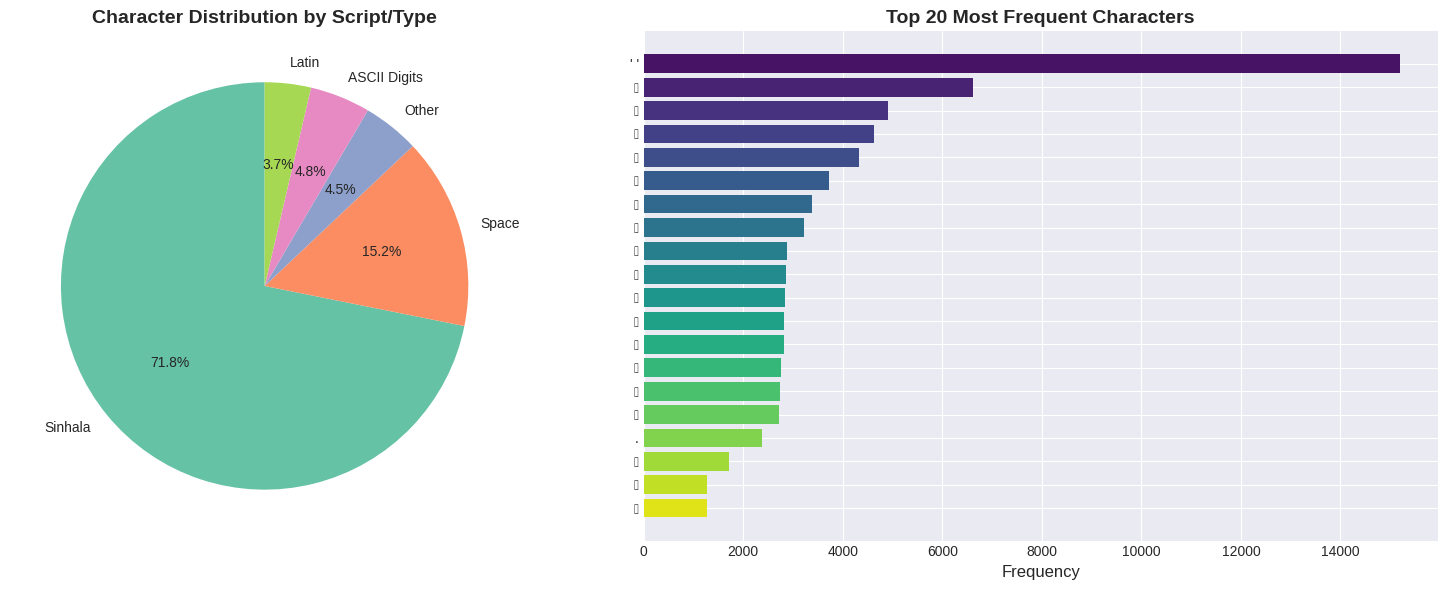


✓ Character distribution visualized


In [9]:
# Visualize character distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Script distribution pie chart
script_data = unicode_analysis['ranges']
scripts = list(script_data.keys())
counts = list(script_data.values())

colors = sns.color_palette("Set2", len(scripts))
ax1.pie(counts, labels=scripts, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Character Distribution by Script/Type', fontsize=14, fontweight='bold')

# Top 20 most frequent characters
top_chars = unicode_analysis['char_frequency'].most_common(20)
chars = [char if char not in ['\n', ' ', '\t'] else repr(char) for char, _ in top_chars]
freqs = [count for _, count in top_chars]

ax2.barh(range(len(chars)), freqs, color=sns.color_palette("viridis", len(chars)))
ax2.set_yticks(range(len(chars)))
ax2.set_yticklabels(chars, fontsize=10)
ax2.set_xlabel('Frequency', fontsize=12)
ax2.set_title('Top 20 Most Frequent Characters', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✓ Character distribution visualized")

## 6. Vocabulary Analysis

Deep dive into word-level statistics to understand vocabulary richness and identify specialized terms.

In [10]:
def analyze_vocabulary(text, max_words=None):
    """
    Comprehensive vocabulary analysis.

    This helps identify:
    - Frequency distributions (Zipf's law patterns)
    - Rare vs common words (important for vocabulary extension decisions)
    - Potential technical terms (Buddhist/Pali terminology)
    """
    # Basic tokenization (split on whitespace)
    # Note: This is simplified - actual Sinhala tokenization may need more sophistication
    words = text.split()

    if max_words:
        words = words[:max_words]

    word_freq = Counter(words)

    # Calculate statistics
    total_words = len(words)
    unique_words = len(word_freq)

    # Hapax legomena (words appearing only once) - often technical terms or typos
    hapax = sum(1 for count in word_freq.values() if count == 1)

    # Words by frequency bands
    very_rare = sum(1 for count in word_freq.values() if count <= 5)
    rare = sum(1 for count in word_freq.values() if 5 < count <= 20)
    common = sum(1 for count in word_freq.values() if 20 < count <= 100)
    very_common = sum(1 for count in word_freq.values() if count > 100)

    # Word length distribution
    word_lengths = [len(w) for w in words]

    return {
        'total_words': total_words,
        'unique_words': unique_words,
        'word_freq': word_freq,
        'hapax_count': hapax,
        'very_rare': very_rare,
        'rare': rare,
        'common': common,
        'very_common': very_common,
        'word_lengths': word_lengths
    }

print("Analyzing vocabulary (this may take a moment for large corpora)...")
vocab_analysis = analyze_vocabulary(corpus_text)

print("\n" + "="*80)
print("VOCABULARY ANALYSIS")
print("="*80)

print(f"\n📚 VOCABULARY SIZE:")
print(f"  Total words (tokens): {vocab_analysis['total_words']:,}")
print(f"  Unique words (types): {vocab_analysis['unique_words']:,}")
print(f"  Type-Token Ratio: {vocab_analysis['unique_words']/vocab_analysis['total_words']:.4f}")

print(f"\n🔍 WORD FREQUENCY DISTRIBUTION:")
print(f"  Hapax legomena (frequency = 1): {vocab_analysis['hapax_count']:,} ({100*vocab_analysis['hapax_count']/vocab_analysis['unique_words']:.1f}% of vocabulary)")
print(f"  Very rare words (freq ≤ 5): {vocab_analysis['very_rare']:,} ({100*vocab_analysis['very_rare']/vocab_analysis['unique_words']:.1f}%)")
print(f"  Rare words (freq 6-20): {vocab_analysis['rare']:,} ({100*vocab_analysis['rare']/vocab_analysis['unique_words']:.1f}%)")
print(f"  Common words (freq 21-100): {vocab_analysis['common']:,} ({100*vocab_analysis['common']/vocab_analysis['unique_words']:.1f}%)")
print(f"  Very common words (freq > 100): {vocab_analysis['very_common']:,} ({100*vocab_analysis['very_common']/vocab_analysis['unique_words']:.1f}%)")

print(f"\n📏 WORD LENGTH STATISTICS:")
print(f"  Mean word length: {np.mean(vocab_analysis['word_lengths']):.2f} characters")
print(f"  Median word length: {np.median(vocab_analysis['word_lengths']):.0f} characters")
print(f"  Std deviation: {np.std(vocab_analysis['word_lengths']):.2f}")
print(f"  Min word length: {min(vocab_analysis['word_lengths'])} characters")
print(f"  Max word length: {max(vocab_analysis['word_lengths'])} characters")

# Display top 30 most frequent words
print(f"\n🔝 TOP 30 MOST FREQUENT WORDS:")
print(f"{'Rank':<6} {'Word':<30} {'Frequency':>12} {'Percentage':>12}")
print("-" * 62)
for i, (word, count) in enumerate(vocab_analysis['word_freq'].most_common(30), 1):
    percentage = (count / vocab_analysis['total_words']) * 100
    # Truncate very long words for display
    display_word = word if len(word) <= 28 else word[:25] + '...'
    print(f"{i:<6} {display_word:<30} {count:>12,} {percentage:>11.3f}%")

print("="*80)

Analyzing vocabulary (this may take a moment for large corpora)...

VOCABULARY ANALYSIS

📚 VOCABULARY SIZE:
  Total words (tokens): 838,777
  Unique words (types): 133,666
  Type-Token Ratio: 0.1594

🔍 WORD FREQUENCY DISTRIBUTION:
  Hapax legomena (frequency = 1): 83,093 (62.2% of vocabulary)
  Very rare words (freq ≤ 5): 117,372 (87.8%)
  Rare words (freq 6-20): 11,344 (8.5%)
  Common words (freq 21-100): 4,059 (3.0%)
  Very common words (freq > 100): 891 (0.7%)

📏 WORD LENGTH STATISTICS:
  Mean word length: 5.42 characters
  Median word length: 5 characters
  Std deviation: 3.22
  Min word length: 1 characters
  Max word length: 36 characters

🔝 TOP 30 MOST FREQUENT WORDS:
Rank   Word                              Frequency   Percentage
--------------------------------------------------------------
1      -                                    12,315       1.468%
2      වූ                                    8,202       0.978%
3      ද                                     8,014       0.95

/tmp/ipython-input-1795479629.py:54: UserWarning: Glyph 3520 (\N{SINHALA LETTER VAYANNA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1795479629.py:54: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipython-input-1795479629.py:54: UserWarning: Glyph 3542 (\N{SINHALA VOWEL SIGN DIGA PAA-PILLA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1795479629.py:54: UserWarning: Glyph 3503 (\N{SINHALA LETTER ALPAPRAANA DAYANNA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1795479629.py:54: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1795479629.py:54: UserWarning: Glyph 3548 (\N{SINHALA VOWEL SIGN KOMBUVA HAA AELA-PILLA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1795479629.py:54: UserWarning: Glyph 3474 (\N{SINHALA LETTER

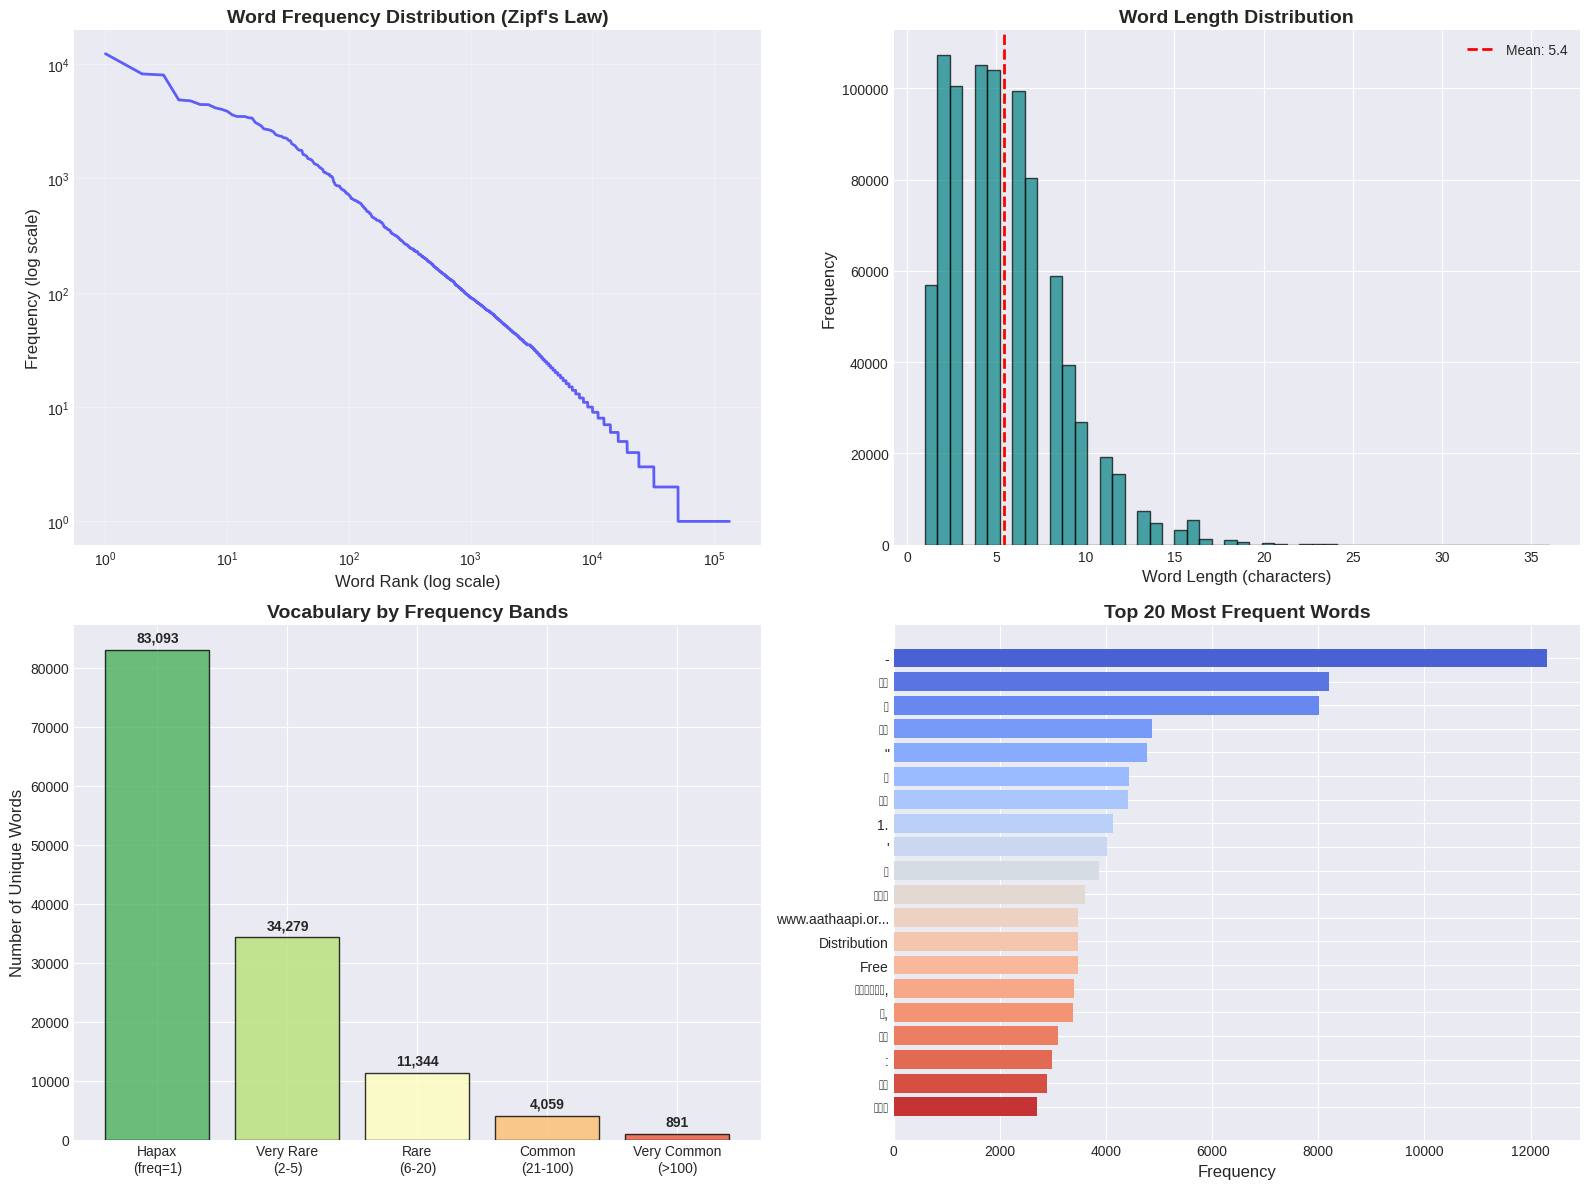


✓ Vocabulary visualizations complete


In [11]:
# Visualize vocabulary distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Word frequency distribution (Zipf's law)
ax1 = axes[0, 0]
frequencies = sorted(vocab_analysis['word_freq'].values(), reverse=True)
ranks = range(1, len(frequencies) + 1)
ax1.loglog(ranks, frequencies, 'b-', alpha=0.6, linewidth=2)
ax1.set_xlabel('Word Rank (log scale)', fontsize=12)
ax1.set_ylabel('Frequency (log scale)', fontsize=12)
ax1.set_title('Word Frequency Distribution (Zipf\'s Law)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Word length distribution
ax2 = axes[0, 1]
ax2.hist(vocab_analysis['word_lengths'], bins=50, color='teal', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Word Length (characters)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Word Length Distribution', fontsize=14, fontweight='bold')
ax2.axvline(np.mean(vocab_analysis['word_lengths']), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(vocab_analysis["word_lengths"]):.1f}')
ax2.legend()

# 3. Vocabulary frequency bands (bar chart)
ax3 = axes[1, 0]
bands = ['Hapax\n(freq=1)', 'Very Rare\n(2-5)', 'Rare\n(6-20)', 'Common\n(21-100)', 'Very Common\n(>100)']
counts = [vocab_analysis['hapax_count'],
          vocab_analysis['very_rare'] - vocab_analysis['hapax_count'],
          vocab_analysis['rare'],
          vocab_analysis['common'],
          vocab_analysis['very_common']]
colors_band = sns.color_palette("RdYlGn_r", len(bands))
ax3.bar(bands, counts, color=colors_band, edgecolor='black', alpha=0.8)
ax3.set_ylabel('Number of Unique Words', fontsize=12)
ax3.set_title('Vocabulary by Frequency Bands', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=0)

# Add count labels on bars
for i, (band, count) in enumerate(zip(bands, counts)):
    ax3.text(i, count + max(counts)*0.01, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# 4. Top 20 words bar chart
ax4 = axes[1, 1]
top_20 = vocab_analysis['word_freq'].most_common(20)
words_top20 = [w[:15] + '...' if len(w) > 15 else w for w, _ in top_20]
counts_top20 = [c for _, c in top_20]
y_pos = np.arange(len(words_top20))
ax4.barh(y_pos, counts_top20, color=sns.color_palette("coolwarm", len(words_top20)))
ax4.set_yticks(y_pos)
ax4.set_yticklabels(words_top20)
ax4.invert_yaxis()
ax4.set_xlabel('Frequency', fontsize=12)
ax4.set_title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Vocabulary visualizations complete")

## 7. Document Structure Analysis

Understanding how documents are organized helps design optimal text chunking for RAG systems.

In [12]:
def analyze_document_structure(text):
    """
    Analyze text structure at document and sentence level.

    This informs:
    - How to chunk texts for RAG retrieval
    - Whether documents are uniform or vary widely in size
    - Presence of very short lines (headers, verse numbers) vs prose
    """
    lines = [line.strip() for line in text.split('\n')]
    non_empty_lines = [line for line in lines if line]

    # Line length statistics
    line_lengths = [len(line) for line in non_empty_lines]

    # Categorize lines by length
    very_short = sum(1 for length in line_lengths if length < 20)  # Headers, verse numbers
    short = sum(1 for length in line_lengths if 20 <= length < 50)
    medium = sum(1 for length in line_lengths if 50 <= length < 100)
    long_lines = sum(1 for length in line_lengths if 100 <= length < 200)
    very_long = sum(1 for length in line_lengths if length >= 200)

    # Estimate sentences (using common Sinhala sentence enders)
    # Sinhala uses කුණ්ඩලිය (.) and other punctuation
    sentence_endings = text.count('.') + text.count('।') + text.count('?') + text.count('!')

    # Detect potential document boundaries
    # Multiple consecutive empty lines often separate documents
    doc_separators = text.count('\n\n\n') + text.count('\n\n\n\n')

    return {
        'total_lines': len(lines),
        'non_empty_lines': len(non_empty_lines),
        'line_lengths': line_lengths,
        'very_short_lines': very_short,
        'short_lines': short,
        'medium_lines': medium,
        'long_lines': long_lines,
        'very_long_lines': very_long,
        'estimated_sentences': sentence_endings,
        'estimated_document_boundaries': doc_separators
    }

print("Analyzing document structure...")
doc_structure = analyze_document_structure(corpus_text)

print("\n" + "="*80)
print("DOCUMENT STRUCTURE ANALYSIS")
print("="*80)

print(f"\n📄 LINE STATISTICS:")
print(f"  Total lines: {doc_structure['total_lines']:,}")
print(f"  Non-empty lines: {doc_structure['non_empty_lines']:,}")
print(f"  Average line length: {np.mean(doc_structure['line_lengths']):.1f} characters")
print(f"  Median line length: {np.median(doc_structure['line_lengths']):.0f} characters")
print(f"  Std deviation: {np.std(doc_structure['line_lengths']):.1f}")

print(f"\n📊 LINE LENGTH DISTRIBUTION:")
total_lines = doc_structure['non_empty_lines']
print(f"  Very short (<20 chars): {doc_structure['very_short_lines']:,} ({100*doc_structure['very_short_lines']/total_lines:.1f}%)")
print(f"  Short (20-49 chars): {doc_structure['short_lines']:,} ({100*doc_structure['short_lines']/total_lines:.1f}%)")
print(f"  Medium (50-99 chars): {doc_structure['medium_lines']:,} ({100*doc_structure['medium_lines']/total_lines:.1f}%)")
print(f"  Long (100-199 chars): {doc_structure['long_lines']:,} ({100*doc_structure['long_lines']/total_lines:.1f}%)")
print(f"  Very long (≥200 chars): {doc_structure['very_long_lines']:,} ({100*doc_structure['very_long_lines']/total_lines:.1f}%)")

print(f"\n📝 ESTIMATED CONTENT UNITS:")
print(f"  Estimated sentences: {doc_structure['estimated_sentences']:,}")
print(f"  Estimated document boundaries: {doc_structure['estimated_document_boundaries']:,}")

if doc_structure['estimated_sentences'] > 0:
    avg_words_per_sentence = basic_stats['total_tokens_whitespace'] / doc_structure['estimated_sentences']
    print(f"  Average words per sentence: {avg_words_per_sentence:.1f}")

print("\n💡 RECOMMENDATIONS:")
if doc_structure['very_short_lines'] / total_lines > 0.3:
    print("  • High proportion of very short lines detected")
    print("    → May include verse numbers, headers, or fragmented extraction")
    print("    → Consider filtering or special handling during preprocessing")

if doc_structure['very_long_lines'] / total_lines > 0.2:
    print("  • Many very long lines detected")
    print("    → Paragraphs may not have line breaks")
    print("    → Consider sentence segmentation during preprocessing")

print("="*80)

Analyzing document structure...

DOCUMENT STRUCTURE ANALYSIS

📄 LINE STATISTICS:
  Total lines: 73
  Non-empty lines: 37
  Average line length: 145595.3 characters
  Median line length: 144329 characters
  Std deviation: 40817.6

📊 LINE LENGTH DISTRIBUTION:
  Very short (<20 chars): 0 (0.0%)
  Short (20-49 chars): 0 (0.0%)
  Medium (50-99 chars): 0 (0.0%)
  Long (100-199 chars): 0 (0.0%)
  Very long (≥200 chars): 37 (100.0%)

📝 ESTIMATED CONTENT UNITS:
  Estimated sentences: 102,681
  Estimated document boundaries: 0
  Average words per sentence: 8.2

💡 RECOMMENDATIONS:
  • Many very long lines detected
    → Paragraphs may not have line breaks
    → Consider sentence segmentation during preprocessing


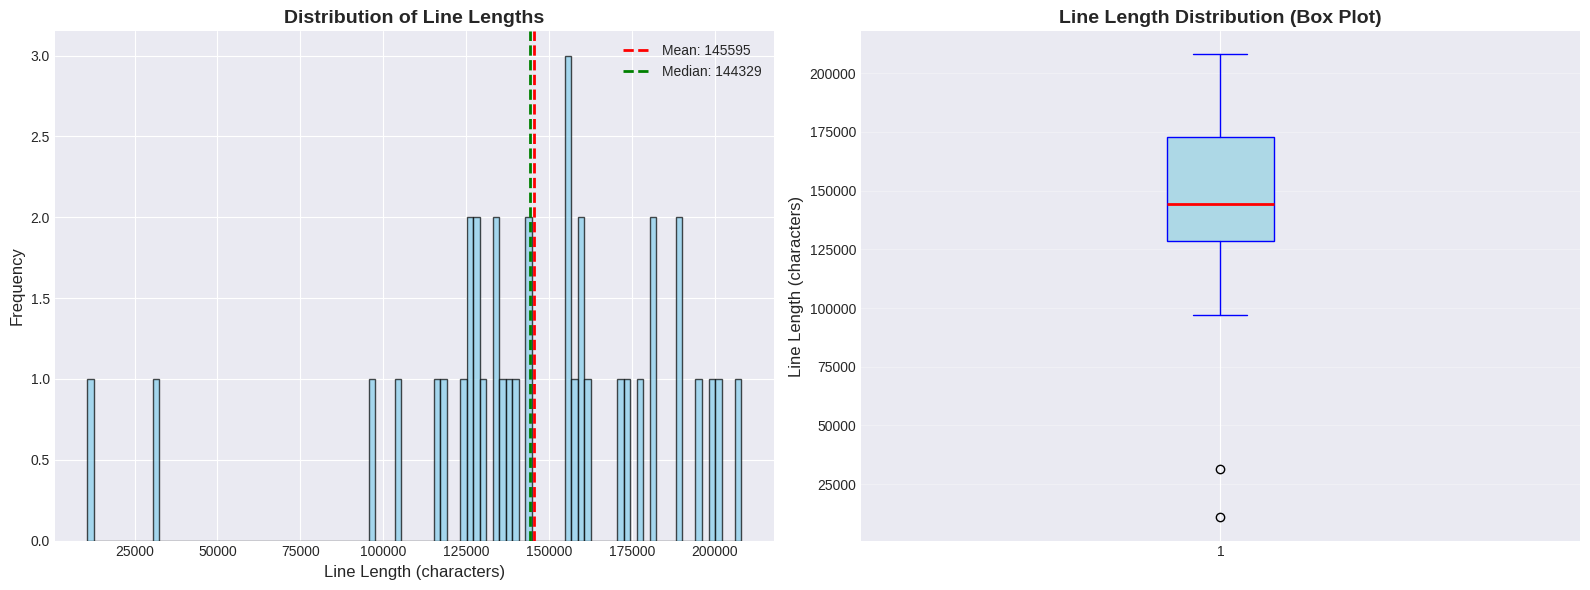


✓ Document structure visualized


In [13]:
# Visualize line length distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of line lengths
ax1 = axes[0]
ax1.hist(doc_structure['line_lengths'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Line Length (characters)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Line Lengths', fontsize=14, fontweight='bold')
ax1.axvline(np.mean(doc_structure['line_lengths']), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(doc_structure["line_lengths"]):.0f}')
ax1.axvline(np.median(doc_structure['line_lengths']), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(doc_structure["line_lengths"]):.0f}')
ax1.legend()

# Box plot showing quartiles
ax2 = axes[1]
ax2.boxplot(doc_structure['line_lengths'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Line Length (characters)', fontsize=12)
ax2.set_title('Line Length Distribution (Box Plot)', fontsize=14, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Document structure visualized")

## 8. Quality Issues Detection

Identify common problems from PDF extraction: repeated headers, page numbers, broken words, etc.

In [14]:
def detect_quality_issues(text, sample_size=10000):
    """
    Detect common text extraction issues and artifacts.

    Common PDF extraction problems:
    - Repeated headers/footers
    - Page numbers interspersed in text
    - Words broken across lines without hyphens
    - Multiple spaces or irregular whitespace
    - Special characters rendered incorrectly
    """
    issues = {}

    # 1. Check for excessive repeated lines (headers/footers)
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    line_freq = Counter(lines)
    # Lines repeated more than 10 times are suspicious
    repeated_lines = [(line, count) for line, count in line_freq.items() if count > 10]
    issues['repeated_lines'] = sorted(repeated_lines, key=lambda x: x[1], reverse=True)[:20]

    # 2. Check for multiple consecutive spaces
    multiple_spaces = len(re.findall(r'  +', text))
    issues['multiple_spaces_count'] = multiple_spaces

    # 3. Check for lines that are just numbers (page numbers)
    number_only_lines = sum(1 for line in lines if line.strip().isdigit())
    issues['number_only_lines'] = number_only_lines

    # 4. Check for very short words (possible fragmentation)
    words = text.split()
    single_char_words = sum(1 for word in words if len(word) == 1 and word not in ['අ', 'ඇ', 'එ', 'ඔ'])
    issues['single_char_words'] = single_char_words

    # 5. Check for irregular line breaks (lines ending mid-word)
    # Sinhala words shouldn't end with certain combining marks
    irregular_breaks = 0
    for i in range(len(lines) - 1):
        if lines[i] and lines[i][-1] in ['්', 'ා', 'ි', 'ී', 'ු', 'ූ', 'ෘ', 'ෙ', 'ේ', 'ෛ', 'ො', 'ෝ', 'ෞ', 'ං', 'ඃ']:
            # These are vowel signs/marks that typically shouldn't end a line
            irregular_breaks += 1
    issues['irregular_line_breaks'] = irregular_breaks

    # 6. Sample random lines for manual inspection
    sample_lines = random.sample(lines, min(50, len(lines)))
    issues['sample_lines'] = sample_lines

    return issues

print("Detecting quality issues (this may take a moment)...")
quality_issues = detect_quality_issues(corpus_text)

print("\n" + "="*80)
print("QUALITY ISSUES DETECTION")
print("="*80)

print(f"\n⚠️  POTENTIAL ISSUES FOUND:")

print(f"\n1. REPEATED LINES (possible headers/footers):")
if quality_issues['repeated_lines']:
    print(f"   Found {len(quality_issues['repeated_lines'])} lines repeated >10 times")
    print(f"\n   Top 10 most repeated lines:")
    for i, (line, count) in enumerate(quality_issues['repeated_lines'][:10], 1):
        display_line = line[:70] + '...' if len(line) > 70 else line
        print(f"   {i}. [{count:4d}x] {display_line}")
else:
    print("   ✓ No excessively repeated lines found")

print(f"\n2. WHITESPACE ISSUES:")
if quality_issues['multiple_spaces_count'] > 100:
    print(f"   ⚠ Found {quality_issues['multiple_spaces_count']:,} instances of multiple consecutive spaces")
    print(f"   → Recommend normalizing whitespace during preprocessing")
else:
    print(f"   ✓ Minimal multiple space issues ({quality_issues['multiple_spaces_count']} instances)")

print(f"\n3. PAGE NUMBERS:")
if quality_issues['number_only_lines'] > 50:
    print(f"   ⚠ Found {quality_issues['number_only_lines']} lines containing only numbers")
    print(f"   → Likely page numbers, should be removed during preprocessing")
else:
    print(f"   ✓ Few number-only lines ({quality_issues['number_only_lines']})")

print(f"\n4. WORD FRAGMENTATION:")
if quality_issues['single_char_words'] > 1000:
    print(f"   ⚠ Found {quality_issues['single_char_words']:,} single-character words")
    print(f"   → May indicate broken words from PDF extraction")
else:
    print(f"   ✓ Acceptable single-character word count ({quality_issues['single_char_words']:,})")

print(f"\n5. IRREGULAR LINE BREAKS:")
if quality_issues['irregular_line_breaks'] > 500:
    print(f"   ⚠ Found {quality_issues['irregular_line_breaks']:,} lines ending with combining marks")
    print(f"   → Words may be broken across lines, consider rejoining during preprocessing")
else:
    print(f"   ✓ Few irregular line breaks ({quality_issues['irregular_line_breaks']})")

print("="*80)

Detecting quality issues (this may take a moment)...

QUALITY ISSUES DETECTION

⚠️  POTENTIAL ISSUES FOUND:

1. REPEATED LINES (possible headers/footers):
   ✓ No excessively repeated lines found

2. WHITESPACE ISSUES:
   ✓ Minimal multiple space issues (0 instances)

3. PAGE NUMBERS:
   ✓ Few number-only lines (0)

4. WORD FRAGMENTATION:
   ⚠ Found 55,972 single-character words
   → May indicate broken words from PDF extraction

5. IRREGULAR LINE BREAKS:
   ✓ Few irregular line breaks (0)


In [15]:
# Display random sample for manual inspection
print("\n" + "="*80)
print("RANDOM SAMPLE FOR MANUAL INSPECTION")
print("="*80)
print("\nPlease review these 20 random lines for quality issues:")
print("(Look for: extraction errors, broken words, artifacts, encoding issues)\n")

for i, line in enumerate(quality_issues['sample_lines'][:20], 1):
    display_line = line[:100] + '...' if len(line) > 100 else line
    print(f"{i:2d}. {display_line}")

print("\n" + "="*80)


RANDOM SAMPLE FOR MANUAL INSPECTION

Please review these 20 random lines for quality issues:
(Look for: extraction errors, broken words, artifacts, encoding issues)

 1. බුද්ධජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා 30 Free Distribution සූත්‍රාන්ත පිටකයෙහි 24 වන ග්‍රන්ථය කුදුගත්සඟි...
 2. බුද්ධජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා:14 සූත්‍රාන්ත පිටකයෙහි 08 වන ග්‍රන්ථය සංයුත්තනිකාය ද්විතීය භාගය නි...
 3. බුද්ධජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා :40 සූත්‍රාන්ත පිටකයෙහි 35 වන ග්‍රන්ථය පෙටකොපදෙසො ලංකා බෞද්ධ මණ්ඩල...
 4. බුද්ධජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා: 18. සූත්‍රාන්තපිටකයෙහි 12 වන ග්‍රන්ථය අංගුත්තරනිකාය ප්‍රථම භාගය එ...
 5. බුද්ධජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා: 8 සූත්‍රාන්ත පිටකයෙහි 02 වත්‍ර ග්‍රන්ථය දීඝනිකාය ද්විතීය භාගය මහව...
 6. බුද්ධ ජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා: 33. සූත්‍රාන්ත පිටකයෙහි 27 වන ග්‍රන්ථය මහානිද්දෙසපාළි ඛුද්දක නික...
 7. බුද්ධජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා: 23 සූත්‍රාන්ත පිටකයෙහි 17 වන ග්‍රන්ථය අංගුත්තර නිකාය ෂෂෂ්ඨ භාගය ද...
 8. බුද්ධ ජයන්ති ත්‍රිපිටකග්‍රන්ථමාලා: 35(ii) සූත්‍රාන්ත පිටකයෙහි 30 වන ග්‍රන

## 9. N-gram Analysis

Identify common multi-word phrases and collocations - useful for understanding Buddhist terminology and formulaic expressions.

In [16]:
def extract_ngrams(text, n=2, top_k=30, min_freq=5):
    """
    Extract most common n-grams (sequences of n words).

    For Buddhist texts, bigrams and trigrams often capture:
    - Technical terms (e.g., "අරිය සත්‍යය" - Noble Truth)
    - Titles and epithets (e.g., "භාග්‍යවත් බුදුරජාණන් වහන්සේ")
    - Formulaic expressions common in suttas
    """
    words = text.split()
    ngrams = []

    for i in range(len(words) - n + 1):
        ngram = ' '.join(words[i:i+n])
        ngrams.append(ngram)

    ngram_freq = Counter(ngrams)

    # Filter by minimum frequency
    filtered_ngrams = {ng: count for ng, count in ngram_freq.items() if count >= min_freq}

    # Get top k
    top_ngrams = Counter(filtered_ngrams).most_common(top_k)

    return top_ngrams

print("Extracting n-grams (this may take a while for large corpora)...")
print("Note: Processing first 500k words for performance")

# Sample text for performance
words_sample = corpus_text.split()[:500000]
sample_text = ' '.join(words_sample)

bigrams = extract_ngrams(sample_text, n=2, top_k=30, min_freq=10)
trigrams = extract_ngrams(sample_text, n=3, top_k=30, min_freq=5)

print("\n" + "="*80)
print("N-GRAM ANALYSIS")
print("="*80)

print(f"\n📌 TOP 30 BIGRAMS (2-word phrases):")
print(f"{'Rank':<6} {'Bigram':<50} {'Frequency':>12}")
print("-" * 70)
for i, (ngram, count) in enumerate(bigrams, 1):
    display_ngram = ngram if len(ngram) <= 48 else ngram[:45] + '...'
    print(f"{i:<6} {display_ngram:<50} {count:>12,}")

print(f"\n📌 TOP 30 TRIGRAMS (3-word phrases):")
print(f"{'Rank':<6} {'Trigram':<50} {'Frequency':>12}")
print("-" * 70)
for i, (ngram, count) in enumerate(trigrams, 1):
    display_ngram = ngram if len(ngram) <= 48 else ngram[:45] + '...'
    print(f"{i:<6} {display_ngram:<50} {count:>12,}")

print("\n💡 N-gram analysis helps identify:")
print("   • Multi-word technical terms (should be kept together during tokenization)")
print("   • Formulaic expressions (common in Buddhist texts)")
print("   • Potential named entities (titles, places, concepts)")
print("   • Candidates for vocabulary extension (if frequently fragmented)")

print("="*80)

Extracting n-grams (this may take a while for large corpora)...
Note: Processing first 500k words for performance

N-GRAM ANALYSIS

📌 TOP 30 BIGRAMS (2-word phrases):
Rank   Bigram                                                Frequency
----------------------------------------------------------------------
1      Free Distribution                                         2,009
2      Distribution www.aathaapi.org                             1,591
3      - පෙ                                                        536
4      පෙ -                                                        534
5      : :                                                         473
6      භාග්‍යවතුන් වහන්සේ                                          451
7      ' යි                                                        305
8      වේ ද,                                                       299
9      " "                                                         278
10     අථ ඛො                                        

## 10. Summary Report and Export

Generate a comprehensive summary report and save all analysis results.

In [22]:
# Create comprehensive summary report
summary_report = f"""
{'='*80}
SINHALA BUDDHIST CORPUS ANALYSIS - COMPREHENSIVE SUMMARY REPORT
{'='*80}
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Corpus File: {CORPUS_FILE_PATH}
{'='*80}

## 1. CORPUS SIZE AND SCOPE

Total Characters: {basic_stats['total_characters']:,}
Total Tokens (whitespace-based): {basic_stats['total_tokens_whitespace']:,}
Unique Tokens: {basic_stats['unique_tokens_whitespace']:,}
Type-Token Ratio: {basic_stats['type_token_ratio']:.4f}
Total Lines: {basic_stats['total_lines']:,}
Non-empty Lines: {basic_stats['non_empty_lines']:,}
Estimated Paragraphs: {basic_stats['estimated_paragraphs']:,}

## 2. VOCABULARY CHARACTERISTICS

Total Words: {vocab_analysis['total_words']:,}
Unique Words: {vocab_analysis['unique_words']:,}
Hapax Legomena: {vocab_analysis['hapax_count']:,} ({100*vocab_analysis['hapax_count']/vocab_analysis['unique_words']:.1f}%)
Very Rare Words (freq ≤5): {vocab_analysis['very_rare']:,}
Rare Words (freq 6-20): {vocab_analysis['rare']:,}
Common Words (freq 21-100): {vocab_analysis['common']:,}
Very Common Words (freq >100): {vocab_analysis['very_common']:,}

## 3. CHARACTER DISTRIBUTION

Total Unique Characters: {unicode_analysis['total_unique_chars']}
Sinhala Characters: {unicode_analysis['ranges'].get('Sinhala', 0):,} ({100*unicode_analysis['ranges'].get('Sinhala', 0)/sum(unicode_analysis['ranges'].values()):.1f}%)
Latin Characters: {unicode_analysis['ranges'].get('Latin', 0):,} ({100*unicode_analysis['ranges'].get('Latin', 0)/sum(unicode_analysis['ranges'].values()):.1f}%)
Control Characters: {unicode_analysis['ranges'].get('Control Characters', 0):,}

## 4. TEXT STRUCTURE

Average Line Length: {np.mean(doc_structure['line_lengths']):.1f} characters
Median Line Length: {np.median(doc_structure['line_lengths']):.0f} characters
Very Short Lines (<20 chars): {doc_structure['very_short_lines']:,} ({100*doc_structure['very_short_lines']/doc_structure['non_empty_lines']:.1f}%)
Very Long Lines (≥200 chars): {doc_structure['very_long_lines']:,} ({100*doc_structure['very_long_lines']/doc_structure['non_empty_lines']:.1f}%)
Estimated Sentences: {doc_structure['estimated_sentences']:,}

## 5. QUALITY ASSESSMENT

Repeated Lines (>10 occurrences): {len(quality_issues['repeated_lines'])}
Multiple Space Issues: {quality_issues['multiple_spaces_count']:,}
Number-only Lines: {quality_issues['number_only_lines']}
Single Character Words: {quality_issues['single_char_words']:,}
Irregular Line Breaks: {quality_issues['irregular_line_breaks']:,}

## 6. KEY RECOMMENDATIONS

### Corpus Suitability for Pretraining:
"""

# Add suitability assessment
token_count = basic_stats['total_tokens_whitespace']
if token_count < 1_000_000:
    summary_report += "⚠️  INSUFFICIENT: Corpus has <1M tokens. Recommended: >10M for effective continual pretraining.\n"
elif token_count < 10_000_000:
    summary_report += "⚠️  MARGINAL: Corpus has <10M tokens. May benefit from additional data collection.\n"
elif token_count < 50_000_000:
    summary_report += "✓ ADEQUATE: Corpus size suitable for continual pretraining (10M-50M tokens).\n"
else:
    summary_report += "✓ EXCELLENT: Large corpus (>50M tokens) - ideal for comprehensive pretraining.\n"

summary_report += f"""
### Lexical Diversity:
"""

if basic_stats['type_token_ratio'] > 0.6:
    summary_report += "✓ HIGH: Rich vocabulary typical of philosophical/religious texts.\n"
elif basic_stats['type_token_ratio'] > 0.4:
    summary_report += "○ MODERATE: Balanced vocabulary for general domain coverage.\n"
else:
    summary_report += "⚠️  LOW: Repetitive content may limit model's vocabulary learning.\n"

summary_report += f"""
### Text Quality:
"""

quality_score = 0
if quality_issues['multiple_spaces_count'] < 1000:
    quality_score += 1
if quality_issues['irregular_line_breaks'] < 1000:
    quality_score += 1
if len(quality_issues['repeated_lines']) < 50:
    quality_score += 1
if unicode_analysis['ranges'].get('Sinhala', 0) / sum(unicode_analysis['ranges'].values()) > 0.7:
    quality_score += 1

if quality_score >= 3:
    summary_report += "✓ GOOD: Minimal extraction artifacts, ready for preprocessing.\n"
elif quality_score >= 2:
    summary_report += "○ FAIR: Some cleanup needed, but manageable quality.\n"
else:
    summary_report += "⚠️  POOR: Significant quality issues require extensive preprocessing.\n"

summary_report += f"""
### Next Steps:

1. PREPROCESSING PRIORITIES:
"""

if quality_issues['multiple_spaces_count'] > 1000:
    summary_report += "   • Normalize whitespace (remove multiple spaces)\n"
if quality_issues['number_only_lines'] > 50:
    summary_report += "   • Remove page numbers and headers\n"
if len(quality_issues['repeated_lines']) > 20:
    summary_report += "   • Filter out repeated headers/footers\n"
if quality_issues['irregular_line_breaks'] > 500:
    summary_report += "   • Rejoin words broken across lines\n"
if unicode_analysis['ranges'].get('Control Characters', 0) > 100:
    summary_report += "   • Remove control characters and artifacts\n"

summary_report += f"""
2. TOKENIZATION APPROACH:
   • Load SinLlama tokenizer
   • Measure vocabulary coverage on this corpus
   • Decide on vocabulary extension based on fragmentation rate

3. CONTINUAL PRETRAINING:
   • Use parameter-efficient methods (LoRA) if compute-limited
   • Monitor perplexity on both Buddhist and general Sinhala text
   • Train for 1-3 epochs with low learning rate (1e-5 to 5e-5)

{'='*80}
END OF REPORT
{'='*80}
"""

print(summary_report)

# Save report to file
report_path = '/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/analysis/corpus_analysis_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(f"\n✓ Summary report saved to: {report_path}")


SINHALA BUDDHIST CORPUS ANALYSIS - COMPREHENSIVE SUMMARY REPORT
Generated: 2025-11-03 08:43:08
Corpus File: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/processed/3_final_corpus/buddhist_corpus_combined_20251101_105228.txt

## 1. CORPUS SIZE AND SCOPE

Total Characters: 5,387,097
Total Tokens (whitespace-based): 838,777
Unique Tokens: 133,666
Type-Token Ratio: 0.1594
Total Lines: 73
Non-empty Lines: 37
Estimated Paragraphs: 37

## 2. VOCABULARY CHARACTERISTICS

Total Words: 838,777
Unique Words: 133,666
Hapax Legomena: 83,093 (62.2%)
Very Rare Words (freq ≤5): 117,372
Rare Words (freq 6-20): 11,344
Common Words (freq 21-100): 4,059
Very Common Words (freq >100): 891

## 3. CHARACTER DISTRIBUTION

Total Unique Characters: 175
Sinhala Characters: 71,848 (71.8%)
Latin Characters: 3,660 (3.7%)
Control Characters: 0

## 4. TEXT STRUCTURE

Average Line Length: 145595.3 characters
Median Line Length: 144329 characters
Very Short Lines (<20 chars): 0 (

In [20]:
# Export detailed statistics to JSON for programmatic use
analysis_data = {
    'metadata': {
        'corpus_file': CORPUS_FILE_PATH,
        'analysis_date': pd.Timestamp.now().isoformat(),
        'detected_encoding': detected_encoding
    },
    'basic_stats': basic_stats,
    'vocabulary_stats': {
        'total_words': vocab_analysis['total_words'],
        'unique_words': vocab_analysis['unique_words'],
        'hapax_count': vocab_analysis['hapax_count'],
        'frequency_bands': {
            'very_rare': vocab_analysis['very_rare'],
            'rare': vocab_analysis['rare'],
            'common': vocab_analysis['common'],
            'very_common': vocab_analysis['very_common']
        },
        'top_30_words': vocab_analysis['word_freq'].most_common(30)
    },
    'unicode_stats': {
        'total_unique_chars': unicode_analysis['total_unique_chars'],
        'script_distribution': unicode_analysis['ranges'],
        'character_categories': unicode_analysis['categories']
    },
    'structure_stats': {
        'total_lines': doc_structure['total_lines'],
        'non_empty_lines': doc_structure['non_empty_lines'],
        'avg_line_length': float(np.mean(doc_structure['line_lengths'])),
        'median_line_length': float(np.median(doc_structure['line_lengths'])),
        'estimated_sentences': doc_structure['estimated_sentences']
    },
    'quality_issues': {
        'repeated_lines_count': len(quality_issues['repeated_lines']),
        'top_repeated_lines': quality_issues['repeated_lines'][:10],
        'multiple_spaces': quality_issues['multiple_spaces_count'],
        'number_only_lines': quality_issues['number_only_lines'],
        'single_char_words': quality_issues['single_char_words'],
        'irregular_line_breaks': quality_issues['irregular_line_breaks']
    },
    'ngrams': {
        'top_bigrams': bigrams[:20],
        'top_trigrams': trigrams[:20]
    }
}

json_path = '/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/analysis/corpus_analysis_data.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(analysis_data, f, ensure_ascii=False, indent=2)

print(f"\n✓ Detailed analysis data exported to: {json_path}")

# Export top words to CSV for easy viewing
top_words_df = pd.DataFrame(
    vocab_analysis['word_freq'].most_common(100),
    columns=['Word', 'Frequency']
)
top_words_df['Percentage'] = (top_words_df['Frequency'] / vocab_analysis['total_words'] * 100).round(3)
csv_path = '/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/analysis/top_100_words.csv'
top_words_df.to_csv(csv_path, index=False, encoding='utf-8')

print(f"✓ Top 100 words exported to: {csv_path}")


✓ Detailed analysis data exported to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/analysis/corpus_analysis_data.json
✓ Top 100 words exported to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/analysis/top_100_words.csv


## 11. Download Results

Download the analysis results to your local machine for further review.

In [23]:
from google.colab import files

print("Preparing files for download...\n")

# Download summary report
print("1. Downloading summary report...")
files.download(report_path)

# Download detailed JSON data
print("2. Downloading detailed analysis data (JSON)...")
files.download(json_path)

# Download top words CSV
print("3. Downloading top 100 words (CSV)...")
files.download(csv_path)

print("\n✓ All files downloaded successfully!")
print("\nYou can also find these files in your Colab session at:")
print(f"  • {report_path}")
print(f"  • {json_path}")
print(f"  • {csv_path}")

Preparing files for download...

1. Downloading summary report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2. Downloading detailed analysis data (JSON)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

3. Downloading top 100 words (CSV)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ All files downloaded successfully!

You can also find these files in your Colab session at:
  • /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/analysis/corpus_analysis_report.txt
  • /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/analysis/corpus_analysis_data.json
  • /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/analysis/top_100_words.csv


## Conclusion and Next Steps

**This analysis has provided:**
1. ✓ Complete statistical profile of your corpus
2. ✓ Unicode and character distribution analysis
3. ✓ Vocabulary richness and frequency distributions
4. ✓ Document structure insights
5. ✓ Quality issue detection and recommendations
6. ✓ N-gram analysis for terminology identification

**Your next steps should be:**
1. Review the summary report and quality issues
2. Design your preprocessing pipeline based on identified issues
3. Proceed to text preprocessing (normalization, cleaning, formatting)
4. Tokenize the preprocessed corpus with SinLlama's tokenizer
5. Measure vocabulary coverage and decide on extension
6. Set up continual pretraining with appropriate hyperparameters

**Questions or need clarification?** Feel free to ask about any aspect of this analysis or the next steps in your pipeline.

---
**Notebook completed successfully!** 🎉